# 09 - Video Processing

Procesamiento de video por lotes, escritura incremental y resumen visual directo.


In [ ]:
from pathlib import Path
import sys

cwd = Path.cwd()
if (cwd / "vision").exists():
    PROJECT_ROOT = cwd
elif len(cwd.parents) >= 3 and (cwd.parents[2] / "vision").exists():
    PROJECT_ROOT = cwd.parents[2]
else:
    PROJECT_ROOT = cwd

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

NOTEBOOK_DIR = PROJECT_ROOT / "vision" / "yolo" / "notebooks"
OUTPUT_DIR = NOTEBOOK_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

IMAGE = (
    str(NOTEBOOK_DIR / "bus.jpg")
    if (NOTEBOOK_DIR / "bus.jpg").exists()
    else "https://ultralytics.com/images/bus.jpg"
)

from vision.yolo.video import (
    video_frame_generator,
    write_video_predictions,
    write_annotated_video,
    write_annotated_video_from_dataframe,
    get_video_info,
)
from vision.yolo.infer import predict_video
from vision.yolo.plotting import plot_video_statistics, plot_class_distribution

model_type = "yolo26s-pose.pt"

MODEL = (
    str(NOTEBOOK_DIR / model_type)
    if (NOTEBOOK_DIR / model_type).exists()
    else model_type
)


In [ ]:
# Inspeccionar metadata de video
VIDEO = "/home/juan/Downloads/6972528-hd_1920_1080_30fps.mp4"
info = get_video_info(VIDEO)
for key, value in info.items():
    print(f"{key}: {value}")


path: /home/juan/Downloads/6972528-hd_1920_1080_30fps.mp4
width: 1920
height: 1080
fps: 30.0
frame_count: 323
duration_s: 10.766666666666667


In [ ]:
# Iterar frames sin cargar todo el video en memoria
for frames, indices, timestamps in video_frame_generator(
    VIDEO, batch_size=32, max_frames=24
):
    print(
        f"Batch frames={indices[0]}..{indices[-1]} shape={frames[0].shape} ts={timestamps[0]:.2f}"
    )


Batch frames=0..23 shape=(1080, 1920, 3) ts=0.00


In [ ]:
# diccionario de trackers: bytetrack y botsort y cada uno con su configuración
trackers = {
    "bytetrack.yaml": {
        "track_high_thresh": 0.35,  # Higher confidence threshold for associating detections to existing tracks. Default is 0.35.
        "track_low_thresh": 0.05,  # Lower confidence threshold for maintaining tracks. Default is 0.05.
        "new_track_thresh": 0.35,  # Confidence threshold for creating new tracks. Default is 0.35.
        "track_buffer": 150,  # Number of frames to buffer for track matching. Default is 150.
        "match_thresh": 0.6,  # IoU threshold for matching detections to tracks. Default is 0.6.
        "fuse_score": True,  # Whether to fuse detection scores with track scores. Default is True.
    },
    "botsort.yaml": {
        "tracker_type": "botsort",  # (str) Tracker backend: botsort|bytetrack; choose botsort to enable BoT-SORT features
        "track_high_thresh": 0.25,  # (float) First-stage match threshold; raise for cleaner tracks, lower to keep more
        "track_low_thresh": 0.1,  # (float) Second-stage threshold for low-score matches; balances recovery vs drift
        "new_track_thresh": 0.25,  # (float) Start a new track if no match ≥ this; higher reduces false tracks
        "track_buffer": 30,  # (int) Frames to keep lost tracks alive; higher handles occlusion, increases ID switches risk
        "match_thresh": 0.8,  # (float) Association similarity threshold (IoU/cost); tune with detector quality
        "fuse_score": True,  # (bool) Fuse detection score with motion/IoU for matching; stabilizes weak detections
        # BoT-SORT specifics
        "gmc_method": "sparseOptFlow",  # (str) Global motion compensation: sparseOptFlow|orb|sift|ecc|none; helps moving camera scenes
        # ReID model related thresh
        "proximity_thresh": 0.5,  # (float) Min IoU to consider tracks proximate for ReID; higher is stricter
        "appearance_thresh": 0.8,  # (float) Min appearance similarity for ReID; raise to avoid identity swaps
        "with_reid": False,  # (bool) Enable ReID model use; needs extra model and compute
        "model": "auto",  # (str) ReID model name/path; "auto" uses detector features if available
    },
}


In [ ]:
# Inferencia por video con escritura incremental a parquet
from vision.yolo.infer import predict_video

tracker = "botsort.yaml"  # o "botsort.yaml"
tracker_config = trackers[tracker]

df = predict_video(
    MODEL,
    VIDEO,
    confidence=0.25,
    batch_size=64,
    tracker=tracker,
    tracker_config=tracker_config,
    save_to=OUTPUT_DIR / "09_predictions_tracked.parquet",
    imgsz=320,
)
print(df.head())


   frame track_id  class_id class_name  confidence         xmin        ymin  \
0      1     None         0     person    0.911147   466.515015  112.107239   
1      1     None         0     person    0.905215  1204.730591  180.247009   
2      2        1         0     person    0.907512   472.890320  105.906532   
3      2        2         0     person    0.895115  1228.459961  180.526321   
4      3        1         0     person    0.907808   477.229065  100.215935   

          xmax         ymax polygon  mask  \
0   946.999023  1080.000000    None  None   
1  1739.965942  1080.000000    None  None   
2   944.086365  1078.805298    None  None   
3  1745.552490  1080.000000    None  None   
4   941.374817  1078.277710    None  None   

                                           keypoints  timestamp  
0  [[882.7457275390625, 261.145263671875, 0.82979...   0.033333  
1  [[1406.766845703125, 339.8532409667969, 0.9833...   0.033333  
2  [[876.0327758789062, 266.645751953125, 0.86389...   0

In [ ]:
display(df.head())


# unique count of track IDs for class "person"
person_ids = df[df["class_name"] == "person"]["track_id"].unique()
print(f"Person track IDs: {len(person_ids)}")


,frame,track_id,class_id,class_name,confidence,xmin,ymin,xmax,ymax,polygon,mask,keypoints,timestamp
0,1,None,0,person,0.911147,466.515015,112.107239,946.999023,1080.000000,None,None,"[[882.7457275390625, 261.145263671875, 0.82979...",0.033333
1,1,None,0,person,0.905215,1204.730591,180.247009,1739.965942,1080.000000,None,None,"[[1406.766845703125, 339.8532409667969, 0.9833...",0.033333
2,2,1,0,person,0.907512,472.890320,105.906532,944.086365,1078.805298,None,None,"[[876.0327758789062, 266.645751953125, 0.86389...",0.066667
3,2,2,0,person,0.895115,1228.459961,180.526321,1745.552490,1080.000000,None,None,"[[1407.3759765625, 341.72637939453125, 0.98247...",0.066667
4,3,1,0,person,0.907808,477.229065,100.215935,941.374817,1078.277710,None,None,"[[877.0355224609375, 258.4862060546875, 0.8779...",0.100000


Person track IDs: 4


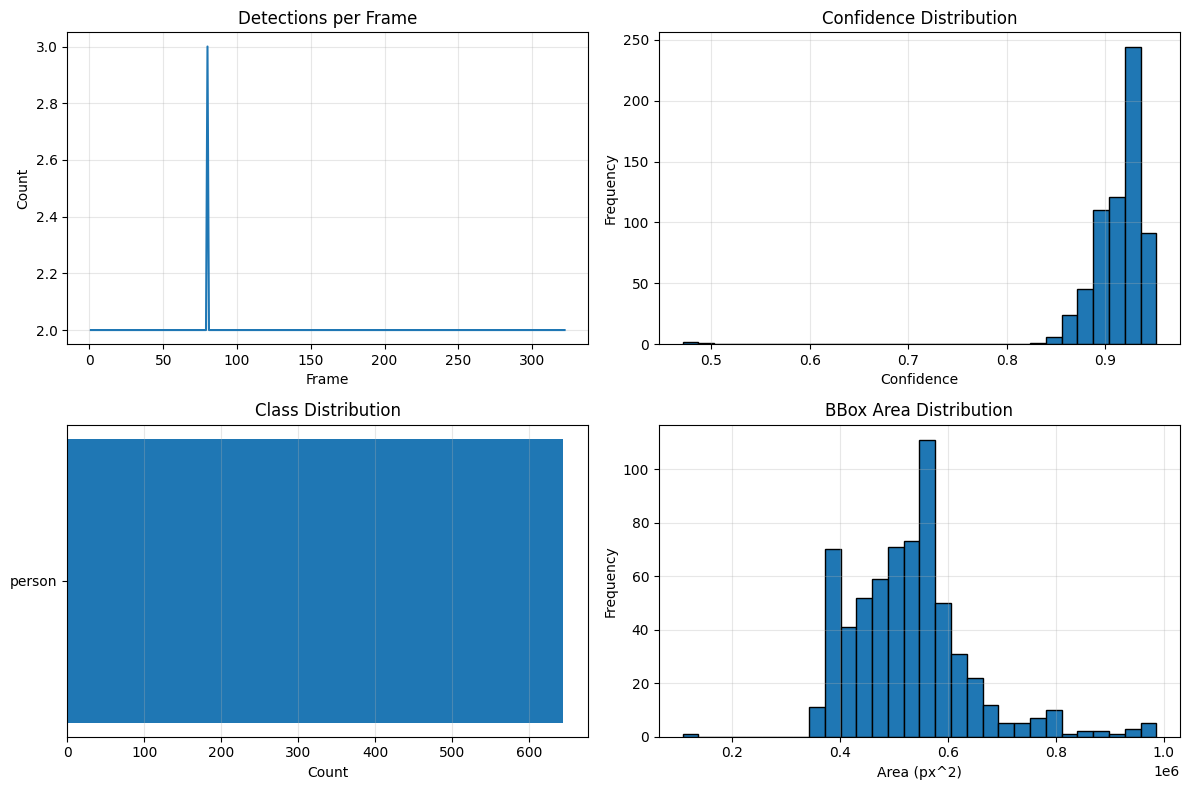

In [ ]:
# Resumenes visuales directos
plot_video_statistics(df, save_to=OUTPUT_DIR / "09_video_statistics.png")


In [ ]:
person_ids = df[df["class_name"] == "person"]["track_id"].unique()
print(f"Person track IDs: {person_ids}")


Person track IDs: [None 1 2 4]


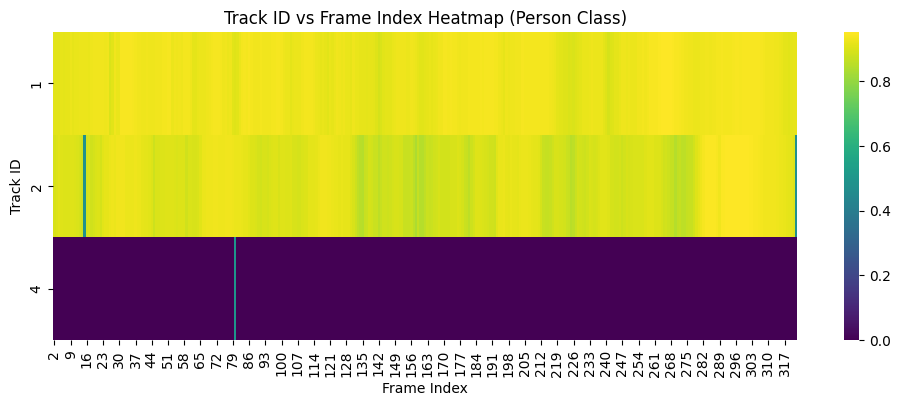

In [ ]:
# hacer un heatmap de track_id vs frame_index para ver la duracion de cada track_id a lo largo del video
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_data = df[df["class_name"] == "person"].pivot_table(
    index="track_id", columns="frame", values="confidence", fill_value=0
)
plt.figure(figsize=(12, 4))
sns.heatmap(heatmap_data, cmap="viridis", cbar=True)
plt.title("Track ID vs Frame Index Heatmap (Person Class)")
plt.xlabel("Frame Index")
plt.ylabel("Track ID")
plt.show()


In [ ]:
# Crear un video anotado desde el DataFrame ya generado por predict_video
# No vuelve a correr el modelo: usa df o el parquet guardado en la celda anterior.
annotated_from_df = write_annotated_video_from_dataframe(
    video_path=VIDEO,
    predictions=df,  # tambien puede ser OUTPUT_DIR / "09_predictions.parquet"
    output_path=OUTPUT_DIR / "09_annotated_from_dataframe.mp4",
    color_by="track_id",  # "class", "track_id" o "confidence"
    draw_boxes=True,
    draw_labels=True,
    draw_polygons=True,
    draw_keypoints=True,
    draw_tails=True,  # usar True si df viene de tracking y tiene track_id
)
print(annotated_from_df)


/home/juan/Documents/GitHub/ultrawrapper/vision/yolo/notebooks/outputs/09_annotated_from_dataframe.mp4
